# World Quant University

### MscFe 690 Capstone project
### Title: Meta-learning Architecture For Predicting Stock Price
### Group: 12528
### Instructor: Saad Zaman
### Prepared By: Sudip Nepal; Indra Pangeni


## Install and Import Dependencies

In [1]:

# Install Libraries

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")

## Define Assets Universe

In [2]:
# List of the assets used in this study
ASSETS = {
    "SPY": "US_Equity",
    "TLT": "US_Bond",
    "GLD": "Commodity",
    "QQQ": "US_Tech_Equity",
    "BTC-USD": "Crypto"
}

## Define Time Period

In [3]:
START_DATE = "2010-01-01"
END_DATE = "2025-12-31"
#END_DATE = datetime.today().strftime("%Y-%m-%d")

## Download Data

In [4]:
def download_assets(assets, start, end):

    data = yf.download(
        list(assets.keys()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker"
    )

    dfs = []

    for ticker in assets.keys():

        df = data[ticker][["Open","High","Low","Close","Adj Close","Volume"]].copy()

        df.columns = [
            f"{ticker}_Open",
            f"{ticker}_High",
            f"{ticker}_Low",
            f"{ticker}_Close",
            f"{ticker}_AdjClose",
            f"{ticker}_Volume"
        ]

        dfs.append(df)

    df_all = pd.concat(dfs, axis=1)

    df_all.index = pd.to_datetime(df_all.index)

    return df_all

price_df = download_assets(ASSETS, START_DATE, END_DATE)

print(price_df.shape)
price_df.head()

(5307, 30)


,SPY_Open,SPY_High,SPY_Low,SPY_Close,SPY_AdjClose,SPY_Volume,TLT_Open,TLT_High,TLT_Low,TLT_Close,...,QQQ_Low,QQQ_Close,QQQ_AdjClose,QQQ_Volume,BTC-USD_Open,BTC-USD_High,BTC-USD_Low,BTC-USD_Close,BTC-USD_AdjClose,BTC-USD_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,85.027962,118944600.0,89.839996,90.099998,89.580002,89.809998,...,46.270000,46.419998,40.341579,62822800.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,113.260002,113.680000,112.849998,113.629997,85.253036,111579900.0,90.050003,90.629997,90.000000,90.389999,...,46.160000,46.419998,40.341579,62935600.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,113.519997,113.989998,113.430000,113.709999,85.313034,116074400.0,90.169998,90.260002,89.120003,89.180000,...,46.070000,46.139999,40.098259,96033000.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,113.500000,114.330002,113.180000,114.190002,85.673218,131091100.0,89.220001,89.639999,89.120003,89.330002,...,45.919998,46.169998,40.124321,77094100.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,113.889999,114.620003,113.660004,114.570000,85.958321,126402800.0,89.510002,89.559998,88.760002,89.290001,...,45.930000,46.549999,40.454571,88886600.0,NaN,NaN,NaN,NaN,NaN,NaN


## Handling Missing Values

In [5]:
price_df = price_df.sort_index()

price_df = price_df.ffill()

price_df = price_df.dropna()

print(price_df.shape)

(4123, 30)


## Exploratory Data Analysis

### Plot log Price History

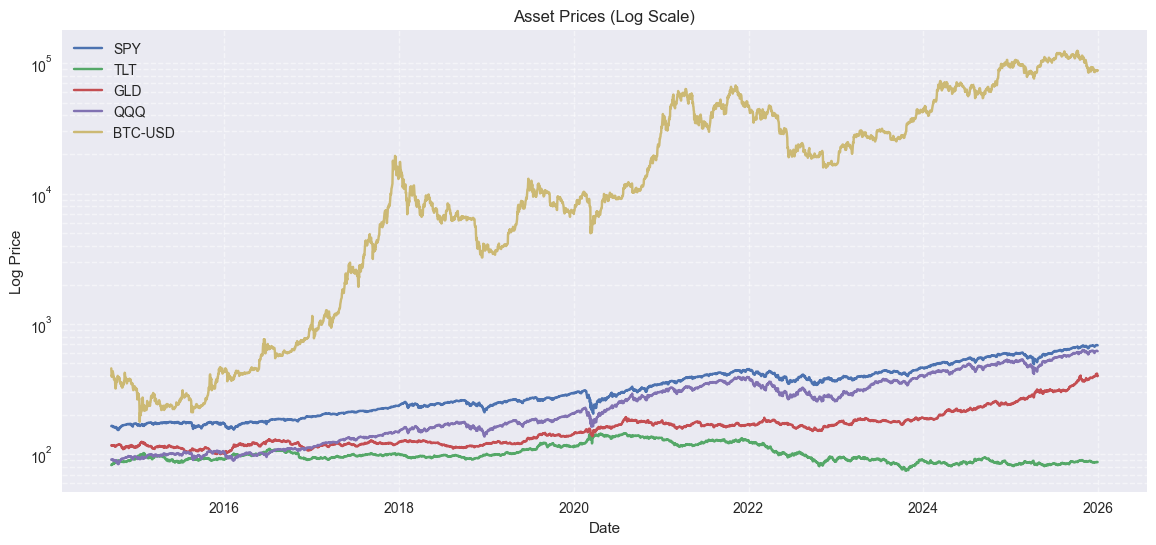

In [6]:
plt.figure(figsize=(14,6))

for ticker in ASSETS.keys():
    plt.plot(
        price_df.index,
        price_df[f"{ticker}_AdjClose"],
        label=ticker
    )

plt.yscale("log")

plt.legend()
plt.title("Asset Prices (Log Scale)")
plt.ylabel("Log Price")
plt.xlabel("Date")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()

### Compute Returns

In [7]:
returns = pd.DataFrame()

for ticker in ASSETS.keys():

    returns[ticker] = price_df[f"{ticker}_AdjClose"].pct_change()

returns.dropna(inplace=True)

### Plot returns

#### Time Series plot

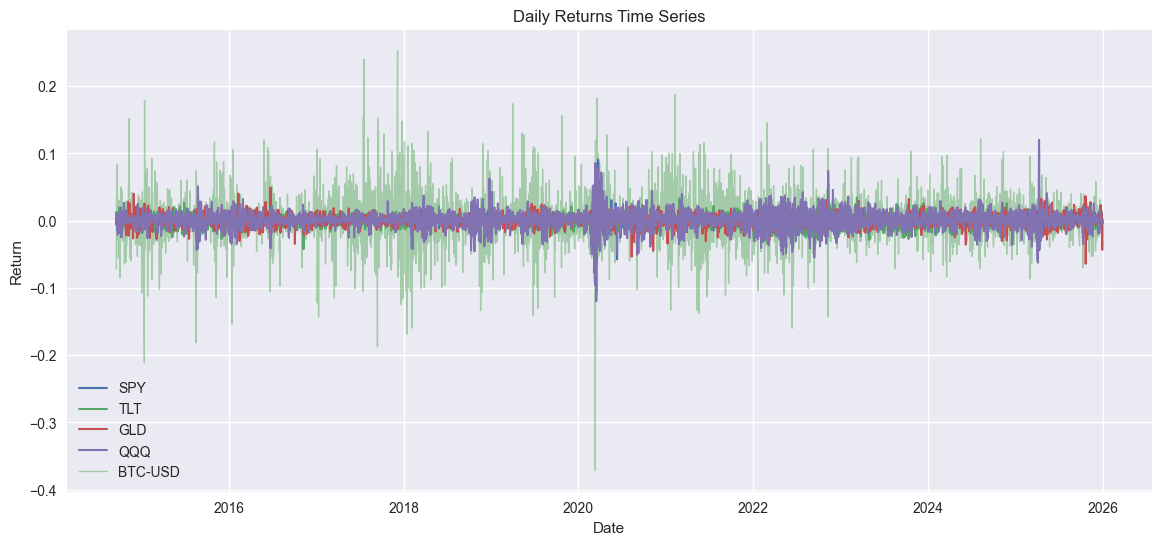

In [8]:
plt.figure(figsize=(14,6))

for ticker in returns.columns:
    if ticker == "BTC-USD":
        plt.plot(returns.index, returns[ticker],
                 label=ticker,
                 color="green",
                 alpha=0.3,
                 linewidth=1,
                 zorder=1)
    else:
        plt.plot(returns.index, returns[ticker],
                 label=ticker,
                 linewidth=1.5,
                 zorder=3)

plt.title("Daily Returns Time Series")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

#### Log-Normalized Plot

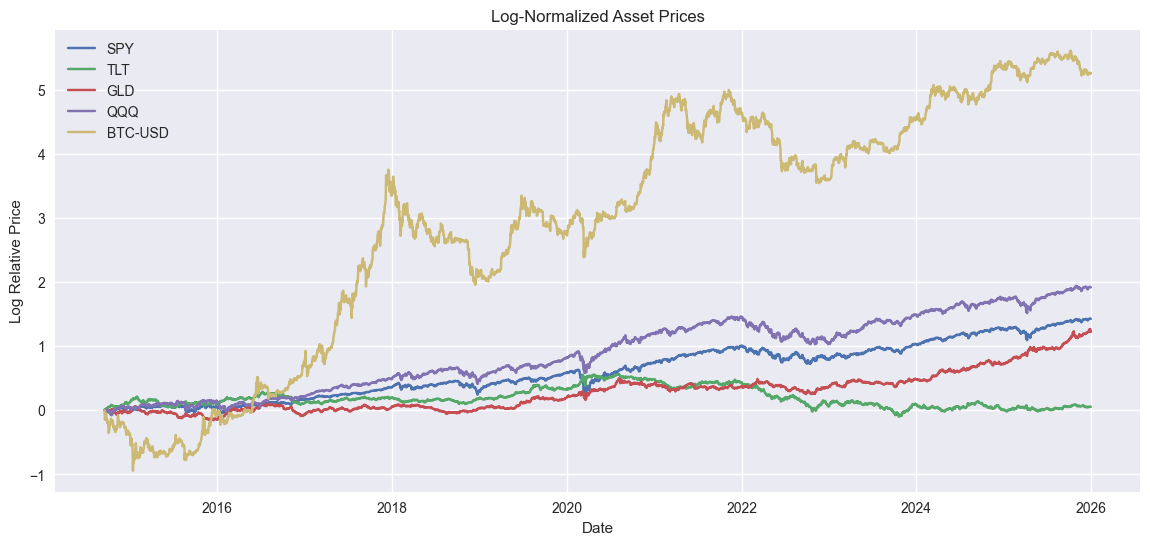

In [9]:
plt.figure(figsize=(14,6))

for ticker in ASSETS.keys():

    price = price_df[f"{ticker}_AdjClose"]
    first_valid = price.loc[price.first_valid_index()]

    log_norm = np.log(price / first_valid)

    plt.plot(price_df.index, log_norm, label=ticker)

plt.legend()
plt.title("Log-Normalized Asset Prices")
plt.ylabel("Log Relative Price")
plt.xlabel("Date")
plt.grid(True)
plt.show()

#### Histograms plot

<Figure size 1400x800 with 0 Axes>

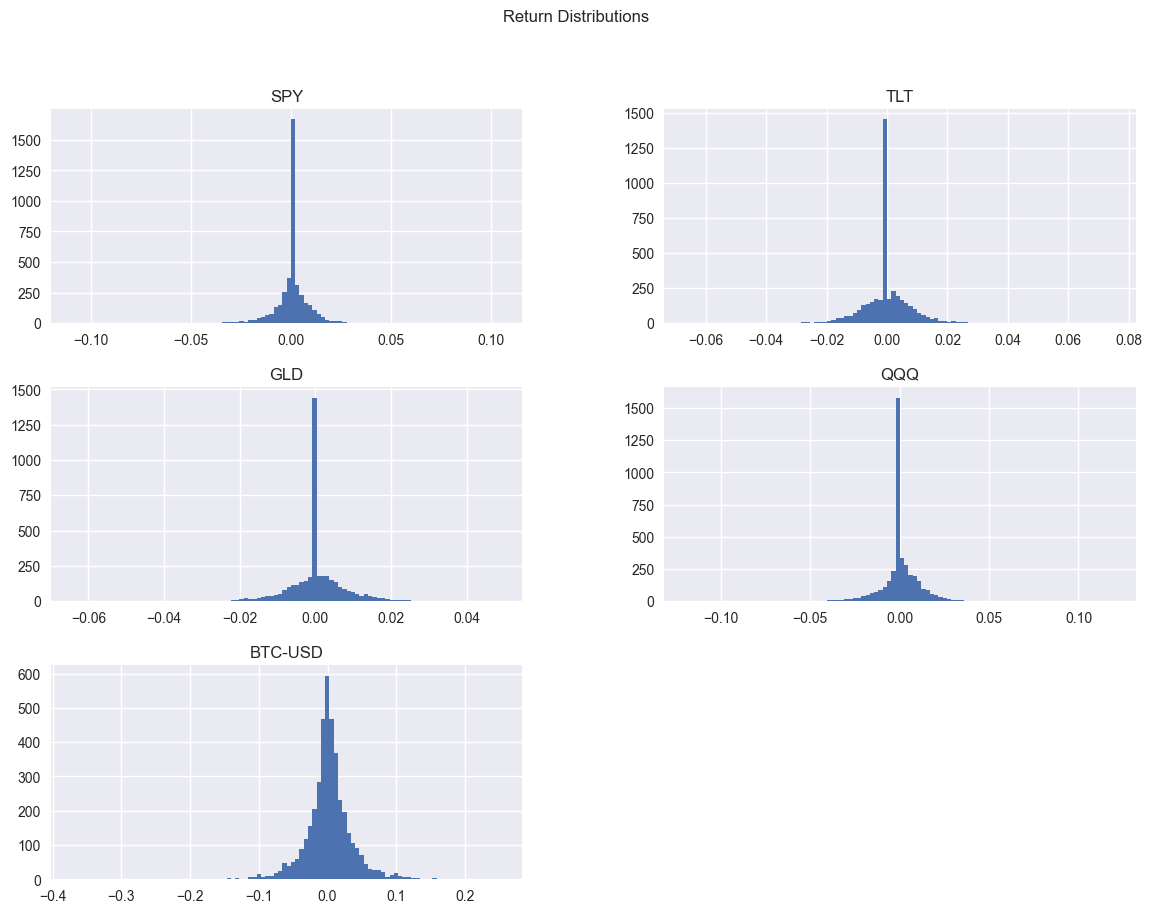

In [10]:
plt.figure(figsize=(14,8))

returns.hist(
    bins=100,
    figsize=(14,10),
    layout=(len(returns.columns)//2+1, 2)
)

plt.suptitle("Return Distributions")
plt.show()

#### Box plot

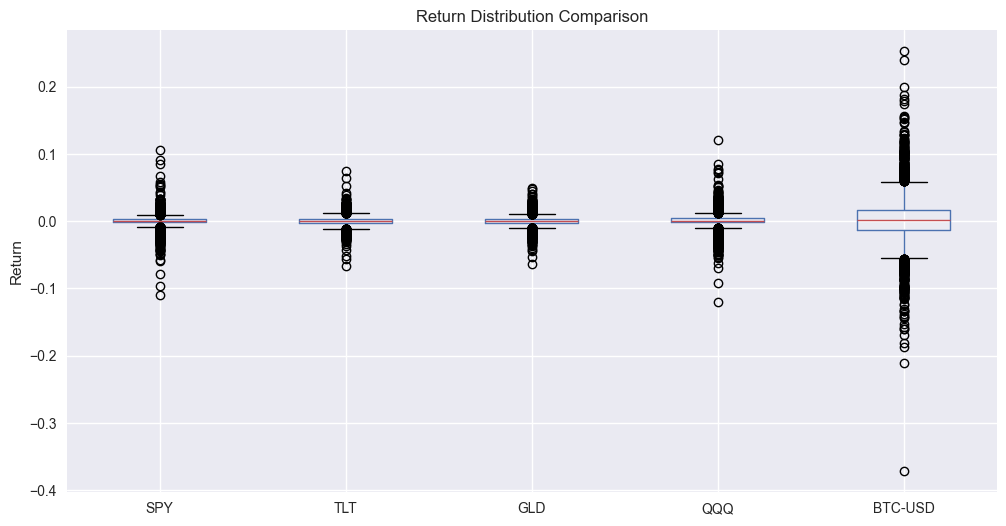

In [11]:
plt.figure(figsize=(12,6))

returns.boxplot()

plt.title("Return Distribution Comparison")
plt.ylabel("Return")
plt.grid(True)
plt.show()

#### 30-day rolling Volatility plot

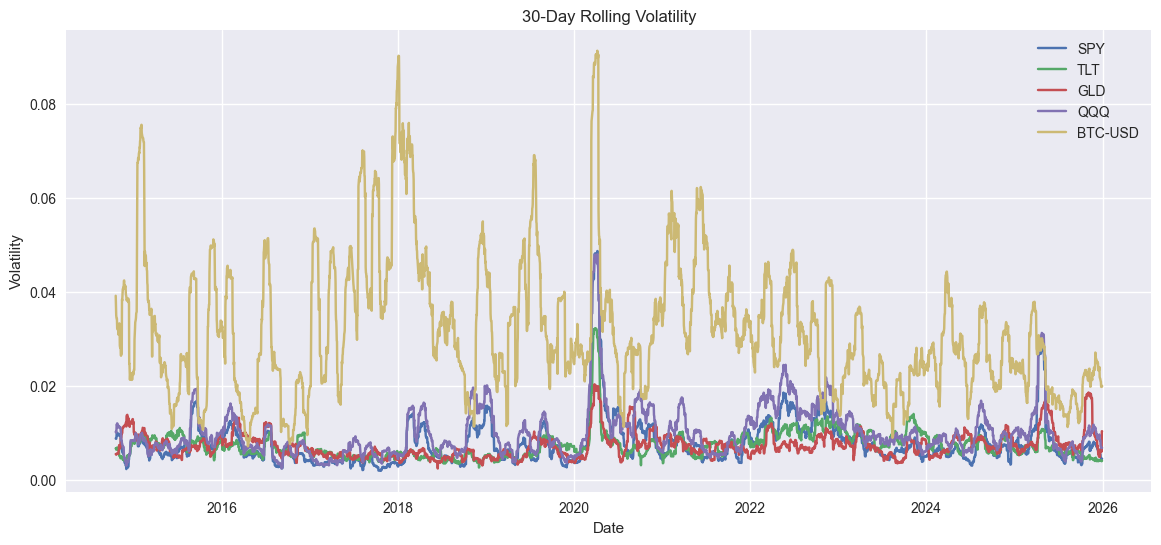

In [12]:
rolling_vol = returns.rolling(30).std()

plt.figure(figsize=(14,6))

for ticker in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

#### Correlation Matrix

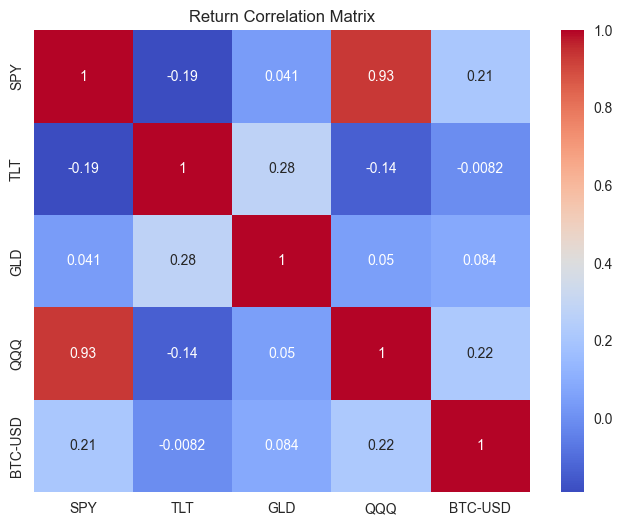

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Return Correlation Matrix")
plt.show()

## Feature Engineering

### Returns 

#### Daily Returns

In [14]:
def compute_daily_return(price_df, assets):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        df = pd.DataFrame(index=price.index)

        df[f"{ticker}_ret_1"] = price.pct_change(1)

        result.append(df)

    return pd.concat(result, axis=1)
#daily_returns = compute_daily_return(price_df, ASSETS)

#### Rolling Returns

In [15]:
def compute_rolling_returns(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        df = pd.DataFrame(index=price.index)

        for w in windows:

            df[f"{ticker}_ret_{w}"] = price.pct_change(w)

        result.append(df)

    return pd.concat(result, axis=1)
#rolling_returns = compute_rolling_returns(price_df, ASSETS)

#### Mean Returns

In [16]:
def compute_return_mean(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        returns = price.pct_change()

        df = pd.DataFrame(index=price.index)

        for w in windows:

            df[f"{ticker}_ret_mean_{w}"] = returns.rolling(w).mean()

        result.append(df)

    return pd.concat(result, axis=1)
#mean_returns = compute_return_mean(price_df, ASSETS)

#### Combining returns

In [17]:
daily_ret = compute_daily_return(price_df, ASSETS.keys())

rolling_ret = compute_rolling_returns(price_df, ASSETS.keys())

mean_ret = compute_return_mean(price_df, ASSETS.keys())

return_features = pd.concat([
    daily_ret,
    rolling_ret,
    mean_ret
], axis=1)
return_features.head()

,SPY_ret_1,TLT_ret_1,GLD_ret_1,QQQ_ret_1,BTC-USD_ret_1,SPY_ret_5,SPY_ret_10,SPY_ret_20,SPY_ret_50,TLT_ret_5,...,GLD_ret_mean_20,GLD_ret_mean_50,QQQ_ret_mean_5,QQQ_ret_mean_10,QQQ_ret_mean_20,QQQ_ret_mean_50,BTC-USD_ret_mean_5,BTC-USD_ret_mean_10,BTC-USD_ret_mean_20,BTC-USD_ret_mean_50
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,0.005330,0.003191,0.002042,0.007536,-0.071926,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,-0.000901,0.012725,-0.005858,-0.000620,-0.069843,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,0.000000,0.000000,0.000000,0.000000,0.035735,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,0.000000,0.000000,0.000000,0.000000,-0.024659,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Moving Averages 

In [18]:
def compute_moving_averages(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        df = pd.DataFrame(index=price.index)

        for w in windows:

            ma = price.rolling(w).mean()

            df[f"{ticker}_ma_{w}"] = ma
            df[f"{ticker}_ma_ratio_{w}"] = price / ma

        result.append(df)

    return pd.concat(result, axis=1)
moving_averages = compute_moving_averages(price_df, ASSETS)
moving_averages.head()

,SPY_ma_5,SPY_ma_ratio_5,SPY_ma_10,SPY_ma_ratio_10,SPY_ma_20,SPY_ma_ratio_20,SPY_ma_50,SPY_ma_ratio_50,TLT_ma_5,TLT_ma_ratio_5,...,QQQ_ma_50,QQQ_ma_ratio_50,BTC-USD_ma_5,BTC-USD_ma_ratio_5,BTC-USD_ma_10,BTC-USD_ma_ratio_10,BTC-USD_ma_20,BTC-USD_ma_ratio_20,BTC-USD_ma_50,BTC-USD_ma_ratio_50
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,165.630908,1.000701,NaN,NaN,NaN,NaN,NaN,NaN,83.705568,1.005687,...,NaN,NaN,416.859003,0.956729,NaN,NaN,NaN,NaN,NaN,NaN


### Volatility

In [19]:
def compute_volatility(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        returns = price.pct_change()

        df = pd.DataFrame(index=price.index)

        for w in windows:
            df[f"{ticker}_vol_{w}"] = returns.rolling(w).std()

        result.append(df)

    return pd.concat(result, axis=1)
volatility = compute_volatility(price_df, ASSETS)
volatility.head()

,SPY_vol_5,SPY_vol_10,SPY_vol_20,SPY_vol_50,TLT_vol_5,TLT_vol_10,TLT_vol_20,TLT_vol_50,GLD_vol_5,GLD_vol_10,GLD_vol_20,GLD_vol_50,QQQ_vol_5,QQQ_vol_10,QQQ_vol_20,QQQ_vol_50,BTC-USD_vol_5,BTC-USD_vol_10,BTC-USD_vol_20,BTC-USD_vol_50
Date,,,,,,,,,,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Volume

In [20]:
def compute_volume_features(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        volume = price_df[f"{ticker}_Volume"]

        df = pd.DataFrame(index=volume.index)

        df[f"{ticker}_volume"] = volume

        for w in windows:

            vol_ma = volume.rolling(w).mean()

            df[f"{ticker}_volume_ma_{w}"] = vol_ma
            df[f"{ticker}_volume_ratio_{w}"] = volume / vol_ma

        result.append(df)

    return pd.concat(result, axis=1)
volume_features = compute_volume_features(price_df, ASSETS)
volume_features.head()

,SPY_volume,SPY_volume_ma_5,SPY_volume_ratio_5,SPY_volume_ma_10,SPY_volume_ratio_10,SPY_volume_ma_20,SPY_volume_ratio_20,SPY_volume_ma_50,SPY_volume_ratio_50,TLT_volume,...,QQQ_volume_ratio_50,BTC-USD_volume,BTC-USD_volume_ma_5,BTC-USD_volume_ratio_5,BTC-USD_volume_ma_10,BTC-USD_volume_ratio_10,BTC-USD_volume_ma_20,BTC-USD_volume_ratio_20,BTC-USD_volume_ma_50,BTC-USD_volume_ratio_50
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,151266000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12917000.0,...,NaN,21056800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,94990000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7031200.0,...,NaN,34483200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,121649000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13236900.0,...,NaN,37919700.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,121649000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13236900.0,...,NaN,36863600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,121649000.0,122240600.0,0.99516,NaN,NaN,NaN,NaN,NaN,NaN,13236900.0,...,NaN,26580100.0,31380680.0,0.847021,NaN,NaN,NaN,NaN,NaN,NaN


## Momentum

In [21]:
def compute_momentum(price_df, assets, windows=[5,10,20,50]):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        df = pd.DataFrame(index=price.index)

        for w in windows:

            df[f"{ticker}_mom_{w}"] = price - price.shift(w)
            df[f"{ticker}_mom_pct_{w}"] = price.pct_change(w)

        result.append(df)

    return pd.concat(result, axis=1)
momentum = compute_momentum(price_df, ASSETS)
momentum.head()

,SPY_mom_5,SPY_mom_pct_5,SPY_mom_10,SPY_mom_pct_10,SPY_mom_20,SPY_mom_pct_20,SPY_mom_50,SPY_mom_pct_50,TLT_mom_5,TLT_mom_pct_5,...,QQQ_mom_50,QQQ_mom_pct_50,BTC-USD_mom_5,BTC-USD_mom_pct_5,BTC-USD_mom_10,BTC-USD_mom_pct_10,BTC-USD_mom_20,BTC-USD_mom_pct_20,BTC-USD_mom_50,BTC-USD_mom_pct_50
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### RSI

In [22]:
def compute_RSI(price_df, assets, window=14):

    result = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        delta = price.diff()

        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        avg_gain = gain.rolling(window).mean()
        avg_loss = loss.rolling(window).mean()

        rs = avg_gain / avg_loss

        rsi = 100 - (100 / (1 + rs))

        df = pd.DataFrame(index=price.index)
        df[f"{ticker}_RSI_{window}"] = rsi

        result.append(df)

    return pd.concat(result, axis=1)
rsi_14 = compute_RSI(price_df, ASSETS)
rsi_14.head()

,SPY_RSI_14,TLT_RSI_14,GLD_RSI_14,QQQ_RSI_14,BTC-USD_RSI_14
Date,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN
2014-09-21,NaN,NaN,NaN,NaN,NaN


### Combining all features

In [23]:
features = pd.concat([
    return_features,
    moving_averages,
    volatility,
    volume_features,
    momentum,
    rsi_14
], axis=1)

# Keeping only rows where at least 95% features exist
threshold = int(features.shape[1] * 0.95)

features.dropna(inplace = True)

print(features.shape)

(4073, 195)


## Models for multi-horizon prediction target

### Data Preparation

#### Create regression targets

In [24]:
import pandas as pd

HORIZONS = [1, 5, 15, 30, 50]

def create_targets(price_df, assets, horizons):

    targets = []

    for ticker in assets:

        price = price_df[f"{ticker}_AdjClose"]

        df = pd.DataFrame(index=price.index)

        for h in horizons:

            df[f"{ticker}_target_{h}d"] = price.shift(-h) / price - 1

        targets.append(df)

    return pd.concat(targets, axis=1)


targets = create_targets(price_df, ASSETS, HORIZONS)

print("Targets shape:", targets.shape)
print("NaNs:", targets.isna().sum().sum())

Targets shape: (4123, 25)
NaNs: 505


#### Align Feature and Targets

In [25]:
# Combine features and targets
dataset = features.join(targets)

print("Before dropna:", dataset.shape)

# Drop rows with any NaNs
dataset.dropna(inplace=True)

print("After dropna:", dataset.shape)

# Separate back features and targets
features_aligned = dataset[features.columns]
targets_aligned  = dataset[targets.columns]

print("Aligned features shape:", features_aligned.shape)
print("Aligned targets shape:", targets_aligned.shape)

Before dropna: (4073, 220)
After dropna: (4023, 220)
Aligned features shape: (4023, 195)
Aligned targets shape: (4023, 25)


#### Train, Validation. and Test split

In [26]:
# Determine split indices
n = len(features_aligned)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Train, validation, test splits
X_train = features_aligned.iloc[:train_end]
X_val   = features_aligned.iloc[train_end:val_end]
X_test  = features_aligned.iloc[val_end:]

y_train = targets_aligned.iloc[:train_end]
y_val   = targets_aligned.iloc[train_end:val_end]
y_test  = targets_aligned.iloc[val_end:]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2816, 195)
X_val shape: (603, 195)
X_test shape: (604, 195)
y_train shape: (2816, 25)
y_val shape: (603, 25)
y_test shape: (604, 25)


#### Standardize Features

In [27]:
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()

# Fit on training set and transform all sets
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

###  Train Ridge Linear Regression

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Assume features and targets are ready
# features.shape -> (4123, 195)
# targets.shape -> (4123, 25)  # e.g., 5 horizons for 5 assets

# 1. Drop any remaining NaNs in features and targets
dataset = features.join(targets)
dataset.dropna(inplace=True)

# 2. Split X and y
X = dataset[features.columns]
y = dataset[targets.columns]

# 3. Split into train (70%), validation (15%), test (15%)
train_size = 0.7
val_size = 0.15

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, shuffle=False)
val_relative = val_size / (1 - train_size)  # adjust relative to remaining
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1-val_relative, shuffle=False)

# 4. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# 5. Train Ridge regression for each target column
ridge_models = {}
pred_train = pd.DataFrame(index=X_train.index)
pred_val   = pd.DataFrame(index=X_val.index)
pred_test  = pd.DataFrame(index=X_test.index)

for col in y.columns:
    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train[col])
    
    ridge_models[col] = model
    
    pred_train[col] = model.predict(X_train_scaled)
    pred_val[col]   = model.predict(X_val_scaled)
    pred_test[col]  = model.predict(X_test_scaled)
    
    print(f"{col} -> Train RMSE: {np.sqrt(mean_squared_error(y_train[col], pred_train[col])):.4f}, "
          f"Val RMSE: {np.sqrt(mean_squared_error(y_val[col], pred_val[col])):.4f}, "
          f"R2 Val: {r2_score(y_val[col], pred_val[col]):.4f}")

SPY_target_1d -> Train RMSE: 0.0087, Val RMSE: 0.0150, R2 Val: -2.0349
SPY_target_5d -> Train RMSE: 0.0167, Val RMSE: 0.0481, R2 Val: -5.6073
SPY_target_15d -> Train RMSE: 0.0252, Val RMSE: 0.1016, R2 Val: -9.9931
SPY_target_30d -> Train RMSE: 0.0326, Val RMSE: 0.1188, R2 Val: -6.3964
SPY_target_50d -> Train RMSE: 0.0377, Val RMSE: 0.1347, R2 Val: -4.9883
TLT_target_1d -> Train RMSE: 0.0072, Val RMSE: 0.0103, R2 Val: -0.1019
TLT_target_5d -> Train RMSE: 0.0143, Val RMSE: 0.0235, R2 Val: -0.3997
TLT_target_15d -> Train RMSE: 0.0211, Val RMSE: 0.0470, R2 Val: -0.7567
TLT_target_30d -> Train RMSE: 0.0271, Val RMSE: 0.0759, R2 Val: -1.0046
TLT_target_50d -> Train RMSE: 0.0354, Val RMSE: 0.0940, R2 Val: -0.9183
GLD_target_1d -> Train RMSE: 0.0071, Val RMSE: 0.0097, R2 Val: -0.8238
GLD_target_5d -> Train RMSE: 0.0143, Val RMSE: 0.0319, R2 Val: -3.1652
GLD_target_15d -> Train RMSE: 0.0222, Val RMSE: 0.0683, R2 Val: -4.5015
GLD_target_30d -> Train RMSE: 0.0285, Val RMSE: 0.0932, R2 Val: -4.378

### Train Random Forest Regressor

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Dictionaries to store models and predictions
rf_models = {}
rf_pred_train = pd.DataFrame(index=X_train.index)
rf_pred_val   = pd.DataFrame(index=X_val.index)
rf_pred_test  = pd.DataFrame(index=X_test.index)

# Train a Random Forest for each target column
for col in y.columns:
    model = RandomForestRegressor(
        n_estimators=100,   # number of trees
        max_depth=None,     # full depth
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_scaled, y_train[col])
    
    # Store model
    rf_models[col] = model
    
    # Make predictions
    rf_pred_train[col] = model.predict(X_train_scaled)
    rf_pred_val[col]   = model.predict(X_val_scaled)
    rf_pred_test[col]  = model.predict(X_test_scaled)
    
    # Evaluation
    rmse_train = np.sqrt(mean_squared_error(y_train[col], rf_pred_train[col]))
    rmse_val   = np.sqrt(mean_squared_error(y_val[col], rf_pred_val[col]))
    r2_val     = r2_score(y_val[col], rf_pred_val[col])
    
    print(f"{col} -> Train RMSE: {rmse_train:.4f}, Val RMSE: {rmse_val:.4f}, R2 Val: {r2_val:.4f}")

SPY_target_1d -> Train RMSE: 0.0037, Val RMSE: 0.0237, R2 Val: -6.5797
SPY_target_5d -> Train RMSE: 0.0046, Val RMSE: 0.0498, R2 Val: -6.0685
SPY_target_15d -> Train RMSE: 0.0051, Val RMSE: 0.0455, R2 Val: -1.2009
SPY_target_30d -> Train RMSE: 0.0048, Val RMSE: 0.0858, R2 Val: -2.8577
SPY_target_50d -> Train RMSE: 0.0043, Val RMSE: 0.0966, R2 Val: -2.0785
TLT_target_1d -> Train RMSE: 0.0030, Val RMSE: 0.0103, R2 Val: -0.0902
TLT_target_5d -> Train RMSE: 0.0040, Val RMSE: 0.0234, R2 Val: -0.3921
TLT_target_15d -> Train RMSE: 0.0038, Val RMSE: 0.0392, R2 Val: -0.2211
TLT_target_30d -> Train RMSE: 0.0037, Val RMSE: 0.0556, R2 Val: -0.0774
TLT_target_50d -> Train RMSE: 0.0037, Val RMSE: 0.0782, R2 Val: -0.3278
GLD_target_1d -> Train RMSE: 0.0029, Val RMSE: 0.0104, R2 Val: -1.1140
GLD_target_5d -> Train RMSE: 0.0039, Val RMSE: 0.0316, R2 Val: -3.0863
GLD_target_15d -> Train RMSE: 0.0036, Val RMSE: 0.0365, R2 Val: -0.5737
GLD_target_30d -> Train RMSE: 0.0038, Val RMSE: 0.0526, R2 Val: -0.712

### Train XGBoost Regressor

In [30]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Dictionaries to store models and predictions
xgb_models = {}
xgb_pred_train = pd.DataFrame(index=X_train.index)
xgb_pred_val   = pd.DataFrame(index=X_val.index)
xgb_pred_test  = pd.DataFrame(index=X_test.index)

# Train XGBoost for each target column
for col in y.columns:
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_scaled, y_train[col])
    
    # Store the model
    xgb_models[col] = model
    
    # Make predictions
    xgb_pred_train[col] = model.predict(X_train_scaled)
    xgb_pred_val[col]   = model.predict(X_val_scaled)
    xgb_pred_test[col]  = model.predict(X_test_scaled)
    
    # Evaluation
    rmse_train = np.sqrt(mean_squared_error(y_train[col], xgb_pred_train[col]))
    rmse_val   = np.sqrt(mean_squared_error(y_val[col], xgb_pred_val[col]))
    r2_val     = r2_score(y_val[col], xgb_pred_val[col])
    
    print(f"{col} -> Train RMSE: {rmse_train:.4f}, Val RMSE: {rmse_val:.4f}, R2 Val: {r2_val:.4f}")

SPY_target_1d -> Train RMSE: 0.0045, Val RMSE: 0.0259, R2 Val: -8.0683
SPY_target_5d -> Train RMSE: 0.0065, Val RMSE: 0.0428, R2 Val: -4.2140
SPY_target_15d -> Train RMSE: 0.0068, Val RMSE: 0.0532, R2 Val: -2.0105
SPY_target_30d -> Train RMSE: 0.0060, Val RMSE: 0.0759, R2 Val: -2.0174
SPY_target_50d -> Train RMSE: 0.0068, Val RMSE: 0.0948, R2 Val: -1.9665
TLT_target_1d -> Train RMSE: 0.0043, Val RMSE: 0.0107, R2 Val: -0.1922
TLT_target_5d -> Train RMSE: 0.0063, Val RMSE: 0.0225, R2 Val: -0.2848
TLT_target_15d -> Train RMSE: 0.0061, Val RMSE: 0.0388, R2 Val: -0.1990
TLT_target_30d -> Train RMSE: 0.0059, Val RMSE: 0.0559, R2 Val: -0.0888
TLT_target_50d -> Train RMSE: 0.0057, Val RMSE: 0.0719, R2 Val: -0.1237
GLD_target_1d -> Train RMSE: 0.0042, Val RMSE: 0.0079, R2 Val: -0.2246
GLD_target_5d -> Train RMSE: 0.0063, Val RMSE: 0.0240, R2 Val: -1.3678
GLD_target_15d -> Train RMSE: 0.0062, Val RMSE: 0.0378, R2 Val: -0.6843
GLD_target_30d -> Train RMSE: 0.0060, Val RMSE: 0.0507, R2 Val: -0.593

### Train Support Vector Machine (SVM)

In [31]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Dictionaries to store models and predictions
svm_models = {}
svm_pred_train = pd.DataFrame(index=X_train.index)
svm_pred_val   = pd.DataFrame(index=X_val.index)
svm_pred_test  = pd.DataFrame(index=X_test.index)

# Train SVR for each target column
for col in y.columns:
    model = SVR(
        kernel='rbf',     # Radial Basis Function kernel
        C=10,             # Regularization parameter
        epsilon=0.01,     # Insensitive loss margin
        gamma='scale'     # Automatic scaling of kernel
    )
    
    model.fit(X_train_scaled, y_train[col])
    
    # Store model
    svm_models[col] = model
    
    # Make predictions
    svm_pred_train[col] = model.predict(X_train_scaled)
    svm_pred_val[col]   = model.predict(X_val_scaled)
    svm_pred_test[col]  = model.predict(X_test_scaled)
    
    # Evaluation
    rmse_train = np.sqrt(mean_squared_error(y_train[col], svm_pred_train[col]))
    rmse_val   = np.sqrt(mean_squared_error(y_val[col], svm_pred_val[col]))
    r2_val     = r2_score(y_val[col], svm_pred_val[col])
    
    print(f"{col} -> Train RMSE: {rmse_train:.4f}, Val RMSE: {rmse_val:.4f}, R2 Val: {r2_val:.4f}")

SPY_target_1d -> Train RMSE: 0.0061, Val RMSE: 0.0104, R2 Val: -0.4633
SPY_target_5d -> Train RMSE: 0.0075, Val RMSE: 0.0260, R2 Val: -0.9295
SPY_target_15d -> Train RMSE: 0.0077, Val RMSE: 0.0415, R2 Val: -0.8318
SPY_target_30d -> Train RMSE: 0.0079, Val RMSE: 0.0509, R2 Val: -0.3583
SPY_target_50d -> Train RMSE: 0.0081, Val RMSE: 0.0703, R2 Val: -0.6318
TLT_target_1d -> Train RMSE: 0.0060, Val RMSE: 0.0104, R2 Val: -0.1220
TLT_target_5d -> Train RMSE: 0.0074, Val RMSE: 0.0221, R2 Val: -0.2387
TLT_target_15d -> Train RMSE: 0.0078, Val RMSE: 0.0401, R2 Val: -0.2751
TLT_target_30d -> Train RMSE: 0.0078, Val RMSE: 0.0609, R2 Val: -0.2931
TLT_target_50d -> Train RMSE: 0.0081, Val RMSE: 0.0881, R2 Val: -0.6864
GLD_target_1d -> Train RMSE: 0.0060, Val RMSE: 0.0088, R2 Val: -0.5223
GLD_target_5d -> Train RMSE: 0.0075, Val RMSE: 0.0181, R2 Val: -0.3417
GLD_target_15d -> Train RMSE: 0.0078, Val RMSE: 0.0343, R2 Val: -0.3913
GLD_target_30d -> Train RMSE: 0.0080, Val RMSE: 0.0530, R2 Val: -0.737

## Train Meta-Learner

### Create Meta Feature Data Sets

In [32]:
# List of standalone model predictions for validation and test
val_preds = [pred_val, rf_pred_val, xgb_pred_val, svm_pred_val]
test_preds = [pred_test, rf_pred_test, xgb_pred_test, svm_pred_test]

# Column names for meta features
model_names = ['Ridge', 'RandomForest', 'XGBoost', 'SVR']

def compile_meta_features(pred_list, model_names):
    meta_features = pd.DataFrame(index=pred_list[0].index)
    
    for model_name, preds in zip(model_names, pred_list):
        for col in preds.columns:
            meta_features[f"{col}_{model_name}"] = preds[col]
    
    return meta_features

# Compile meta-features
meta_X_val  = compile_meta_features(val_preds, model_names)
meta_X_test = compile_meta_features(test_preds, model_names)

print("Meta-features shape (validation):", meta_X_val.shape)
print("Meta-features shape (test):", meta_X_test.shape)

Meta-features shape (validation): (603, 100)
Meta-features shape (test): (604, 100)


#### Align Meta-Features with Meta-Targets

In [33]:
# Meta targets must align with meta-features index

meta_y_val = y_val.loc[meta_X_val.index].copy()
meta_y_test = y_test.loc[meta_X_test.index].copy()

print("Meta X val:", meta_X_val.shape)
print("Meta y val:", meta_y_val.shape)

print("Meta X test:", meta_X_test.shape)
print("Meta y test:", meta_y_test.shape)

Meta X val: (603, 100)
Meta y val: (603, 25)
Meta X test: (604, 100)
Meta y test: (604, 25)


#### Sanity check

In [34]:
print("NaNs in meta_X_val:", meta_X_val.isna().sum().sum())
print("NaNs in meta_y_val:", meta_y_val.isna().sum().sum())

print("NaNs in meta_X_test:", meta_X_test.isna().sum().sum())
print("NaNs in meta_y_test:", meta_y_test.isna().sum().sum())

NaNs in meta_X_val: 0
NaNs in meta_y_val: 0
NaNs in meta_X_test: 0
NaNs in meta_y_test: 0


### Train Ridge Meta-Learner

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Store models and predictions
ridge_meta_models = {}

meta_pred_val = pd.DataFrame(index=meta_X_val.index)
meta_pred_test = pd.DataFrame(index=meta_X_test.index)

# Train separate Ridge model for each target
for col in meta_y_val.columns:

    model = Ridge(alpha=1.0)

    model.fit(meta_X_val, meta_y_val[col])

    ridge_meta_models[col] = model

    # Predictions
    meta_pred_val[col] = model.predict(meta_X_val)
    meta_pred_test[col] = model.predict(meta_X_test)

    # Metrics
    val_rmse = np.sqrt(mean_squared_error(meta_y_val[col], meta_pred_val[col]))
    val_r2   = r2_score(meta_y_val[col], meta_pred_val[col])

    print(f"{col}")
    print(f"Meta Ridge Val RMSE: {val_rmse:.6f}")
    print(f"Meta Ridge Val R2  : {val_r2:.6f}")
    print("-"*40)

SPY_target_1d
Meta Ridge Val RMSE: 0.008460
Meta Ridge Val R2  : 0.035932
----------------------------------------
SPY_target_5d
Meta Ridge Val RMSE: 0.017059
Meta Ridge Val R2  : 0.169868
----------------------------------------
SPY_target_15d
Meta Ridge Val RMSE: 0.022903
Meta Ridge Val R2  : 0.441224
----------------------------------------
SPY_target_30d
Meta Ridge Val RMSE: 0.028466
Meta Ridge Val R2  : 0.575519
----------------------------------------
SPY_target_50d
Meta Ridge Val RMSE: 0.033004
Meta Ridge Val R2  : 0.640396
----------------------------------------
TLT_target_1d
Meta Ridge Val RMSE: 0.009601
Meta Ridge Val R2  : 0.045293
----------------------------------------
TLT_target_5d
Meta Ridge Val RMSE: 0.018029
Meta Ridge Val R2  : 0.172837
----------------------------------------
TLT_target_15d
Meta Ridge Val RMSE: 0.028703
Meta Ridge Val R2  : 0.345522
----------------------------------------
TLT_target_30d
Meta Ridge Val RMSE: 0.036590
Meta Ridge Val R2  : 0.533563
-

#### Evaluate Ridge Meta-Learner Test Performance

In [36]:
print("\nTEST PERFORMANCE (META RIDGE)")
print("="*50)

meta_results = []

for col in meta_y_test.columns:

    rmse = np.sqrt(mean_squared_error(meta_y_test[col], meta_pred_test[col]))
    r2   = r2_score(meta_y_test[col], meta_pred_test[col])

    meta_results.append({
        "Target": col,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{col}")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R2  : {r2:.6f}")
    print("-"*40)

meta_results_df = pd.DataFrame(meta_results)


TEST PERFORMANCE (META RIDGE)
SPY_target_1d
Test RMSE: 0.009243
Test R2  : -0.056029
----------------------------------------
SPY_target_5d
Test RMSE: 0.019309
Test R2  : -0.045209
----------------------------------------
SPY_target_15d
Test RMSE: 0.039361
Test R2  : -0.884471
----------------------------------------
SPY_target_30d
Test RMSE: 0.036478
Test R2  : 0.111453
----------------------------------------
SPY_target_50d
Test RMSE: 0.047037
Test R2  : 0.059245
----------------------------------------
TLT_target_1d
Test RMSE: 0.007920
Test R2  : -0.302259
----------------------------------------
TLT_target_5d
Test RMSE: 0.025385
Test R2  : -1.624442
----------------------------------------
TLT_target_15d
Test RMSE: 0.044921
Test R2  : -2.243482
----------------------------------------
TLT_target_30d
Test RMSE: 0.117186
Test R2  : -12.348264
----------------------------------------
TLT_target_50d
Test RMSE: 0.134560
Test R2  : -10.120439
----------------------------------------
GLD

### Train Ridge Meta-Learner

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Store models and predictions
xgb_meta_models = {}

meta_pred_val_xgb = pd.DataFrame(index=meta_X_val.index)
meta_pred_test_xgb = pd.DataFrame(index=meta_X_test.index)

# Train separate model for each target
for col in meta_y_val.columns:

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(meta_X_val, meta_y_val[col])

    xgb_meta_models[col] = model

    # Predictions
    meta_pred_val_xgb[col] = model.predict(meta_X_val)
    meta_pred_test_xgb[col] = model.predict(meta_X_test)

    # Validation metrics
    val_rmse = np.sqrt(mean_squared_error(meta_y_val[col], meta_pred_val_xgb[col]))
    val_r2   = r2_score(meta_y_val[col], meta_pred_val_xgb[col])

    print(f"{col}")
    print(f"Meta XGB Val RMSE: {val_rmse:.6f}")
    print(f"Meta XGB Val R2  : {val_r2:.6f}")
    print("-"*40)

SPY_target_1d
Meta XGB Val RMSE: 0.001954
Meta XGB Val R2  : 0.948592
----------------------------------------
SPY_target_5d
Meta XGB Val RMSE: 0.002041
Meta XGB Val R2  : 0.988114
----------------------------------------
SPY_target_15d
Meta XGB Val RMSE: 0.002151
Meta XGB Val R2  : 0.995072
----------------------------------------
SPY_target_30d
Meta XGB Val RMSE: 0.002260
Meta XGB Val R2  : 0.997325
----------------------------------------
SPY_target_50d
Meta XGB Val RMSE: 0.002329
Meta XGB Val R2  : 0.998209
----------------------------------------
TLT_target_1d
Meta XGB Val RMSE: 0.002355
Meta XGB Val R2  : 0.942583
----------------------------------------
TLT_target_5d
Meta XGB Val RMSE: 0.002648
Meta XGB Val R2  : 0.982157
----------------------------------------
TLT_target_15d
Meta XGB Val RMSE: 0.002774
Meta XGB Val R2  : 0.993888
----------------------------------------
TLT_target_30d
Meta XGB Val RMSE: 0.002880
Meta XGB Val R2  : 0.997111
-------------------------------------

#### Evaluate XGBoost Meta-Learner Test Performance

In [38]:
print("\nTEST PERFORMANCE (META XGBOOST)")
print("="*50)

xgb_meta_results = []

for col in meta_y_test.columns:

    rmse = np.sqrt(mean_squared_error(meta_y_test[col], meta_pred_test_xgb[col]))
    r2   = r2_score(meta_y_test[col], meta_pred_test_xgb[col])

    xgb_meta_results.append({
        "Target": col,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{col}")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R2  : {r2:.6f}")
    print("-"*40)

xgb_meta_results_df = pd.DataFrame(xgb_meta_results)


TEST PERFORMANCE (META XGBOOST)
SPY_target_1d
Test RMSE: 0.009824
Test R2  : -0.193138
----------------------------------------
SPY_target_5d
Test RMSE: 0.019835
Test R2  : -0.102862
----------------------------------------
SPY_target_15d
Test RMSE: 0.030252
Test R2  : -0.113165
----------------------------------------
SPY_target_30d
Test RMSE: 0.037310
Test R2  : 0.070442
----------------------------------------
SPY_target_50d
Test RMSE: 0.046022
Test R2  : 0.099425
----------------------------------------
TLT_target_1d
Test RMSE: 0.008145
Test R2  : -0.377620
----------------------------------------
TLT_target_5d
Test RMSE: 0.019356
Test R2  : -0.525867
----------------------------------------
TLT_target_15d
Test RMSE: 0.031737
Test R2  : -0.618948
----------------------------------------
TLT_target_30d
Test RMSE: 0.049293
Test R2  : -1.361791
----------------------------------------
TLT_target_50d
Test RMSE: 0.067502
Test R2  : -1.798518
----------------------------------------
GLD

### Train LSTM Meta-Learner

#### Standarize Data

In [39]:
from sklearn.preprocessing import StandardScaler

meta_scaler = StandardScaler()

meta_X_val_scaled  = meta_scaler.fit_transform(meta_X_val)
meta_X_test_scaled = meta_scaler.transform(meta_X_test)

#### Convert to Sequences

In [41]:
import numpy as np

LOOKBACK = 10

def create_sequences(X, y, lookback):
    
    X_seq = []
    y_seq = []
    index_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y.iloc[i].values)
        index_seq.append(y.index[i])

    return np.array(X_seq), np.array(y_seq), index_seq


X_val_seq, y_val_seq, val_index = create_sequences(
    meta_X_val_scaled,
    meta_y_val,
    LOOKBACK
)

X_test_seq, y_test_seq, test_index = create_sequences(
    meta_X_test_scaled,
    meta_y_test,
    LOOKBACK
)

print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Validation sequence shape: (593, 10, 100)
Test sequence shape: (594, 10, 100)


#### Build LSTM Meta-Learner

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

n_features = X_val_seq.shape[2]
n_targets  = y_val_seq.shape[1]

lstm_meta_model = Sequential([

    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(n_targets)

])

lstm_meta_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

lstm_meta_model.summary()

C:\Users\nplsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          42,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │             825 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,481 (216.72 KB)

 Trainable params: 55,481 (216.72 KB)

 Non-trainable params: 0 (0.00 B)

#### Train LSTM Meta-Learner

In [44]:
history = lstm_meta_model.fit(

    X_val_seq,
    y_val_seq,

    epochs=100,
    batch_size=32,
    verbose=0
)

#### Predict on Validation and Test

In [45]:
meta_pred_val_lstm = lstm_meta_model.predict(X_val_seq)
meta_pred_test_lstm = lstm_meta_model.predict(X_test_seq)

meta_pred_val_lstm = pd.DataFrame(
    meta_pred_val_lstm,
    index=val_index,
    columns=meta_y_val.columns
)

meta_pred_test_lstm = pd.DataFrame(
    meta_pred_test_lstm,
    index=test_index,
    columns=meta_y_test.columns
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


#### Evaluate Validation Performance

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

print("\nVALIDATION PERFORMANCE (META LSTM)")
print("="*50)

for col in meta_y_val.columns:

    rmse = np.sqrt(mean_squared_error(
        meta_y_val.loc[val_index, col],
        meta_pred_val_lstm[col]
    ))

    r2 = r2_score(
        meta_y_val.loc[val_index, col],
        meta_pred_val_lstm[col]
    )

    print(f"{col}")
    print(f"Val RMSE: {rmse:.6f}")
    print(f"Val R2  : {r2:.6f}")
    print("-"*40)


VALIDATION PERFORMANCE (META LSTM)
SPY_target_1d
Val RMSE: 0.008313
Val R2  : 0.059271
----------------------------------------
SPY_target_5d
Val RMSE: 0.012551
Val R2  : 0.542995
----------------------------------------
SPY_target_15d
Val RMSE: 0.012138
Val R2  : 0.840939
----------------------------------------
SPY_target_30d
Val RMSE: 0.011891
Val R2  : 0.926274
----------------------------------------
SPY_target_50d
Val RMSE: 0.012661
Val R2  : 0.946931
----------------------------------------
TLT_target_1d
Val RMSE: 0.009514
Val R2  : 0.058291
----------------------------------------
TLT_target_5d
Val RMSE: 0.014601
Val R2  : 0.460559
----------------------------------------
TLT_target_15d
Val RMSE: 0.014672
Val R2  : 0.831383
----------------------------------------
TLT_target_30d
Val RMSE: 0.014300
Val R2  : 0.929377
----------------------------------------
TLT_target_50d
Val RMSE: 0.014261
Val R2  : 0.955672
----------------------------------------
GLD_target_1d
Val RMSE: 0.00

#### Evaluate Test Performance

In [47]:
print("\nTEST PERFORMANCE (META LSTM)")
print("="*50)

lstm_meta_results = []

for col in meta_y_test.columns:

    rmse = np.sqrt(mean_squared_error(
        meta_y_test.loc[test_index, col],
        meta_pred_test_lstm[col]
    ))

    r2 = r2_score(
        meta_y_test.loc[test_index, col],
        meta_pred_test_lstm[col]
    )

    lstm_meta_results.append({
        "Target": col,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{col}")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R2  : {r2:.6f}")
    print("-"*40)

lstm_meta_results_df = pd.DataFrame(lstm_meta_results)


TEST PERFORMANCE (META LSTM)
SPY_target_1d
Test RMSE: 0.012386
Test R2  : -0.873738
----------------------------------------
SPY_target_5d
Test RMSE: 0.024700
Test R2  : -0.688106
----------------------------------------
SPY_target_15d
Test RMSE: 0.036841
Test R2  : -0.629293
----------------------------------------
SPY_target_30d
Test RMSE: 0.048092
Test R2  : -0.564752
----------------------------------------
SPY_target_50d
Test RMSE: 0.064826
Test R2  : -0.763845
----------------------------------------
TLT_target_1d
Test RMSE: 0.012090
Test R2  : -2.009589
----------------------------------------
TLT_target_5d
Test RMSE: 0.023044
Test R2  : -1.139520
----------------------------------------
TLT_target_15d
Test RMSE: 0.055131
Test R2  : -3.851899
----------------------------------------
TLT_target_30d
Test RMSE: 0.111622
Test R2  : -11.387736
----------------------------------------
TLT_target_50d
Test RMSE: 0.082645
Test R2  : -3.162082
----------------------------------------
GLD

### Comparing Standalone and Meta-Leraner Models

#### Align All Predictions

In [48]:
from sklearn.linear_model import Ridge

# Train Ridge meta learner
ridge_meta_model = Ridge(alpha=1.0)

ridge_meta_model.fit(meta_X_val, meta_y_val)

# Create predictions
meta_pred_test_ridge = pd.DataFrame(
    ridge_meta_model.predict(meta_X_test),
    index=meta_X_test.index,
    columns=meta_y_test.columns
)

meta_pred_val_ridge = pd.DataFrame(
    ridge_meta_model.predict(meta_X_val),
    index=meta_X_val.index,
    columns=meta_y_val.columns
)

print("Ridge meta predictions created:")
print(meta_pred_test_ridge.shape)
common_index = y_test.index

common_index = common_index.intersection(pred_test.index)
common_index = common_index.intersection(rf_pred_test.index)
common_index = common_index.intersection(xgb_pred_test.index)
common_index = common_index.intersection(svm_pred_test.index)
common_index = common_index.intersection(meta_pred_test_ridge.index)
common_index = common_index.intersection(meta_pred_test_xgb.index)
common_index = common_index.intersection(meta_pred_test_lstm.index)

# Align all
y_test_aligned = y_test.loc[common_index]

ridge_test  = pred_test.loc[common_index]
rf_test     = rf_pred_test.loc[common_index]
xgb_test    = xgb_pred_test.loc[common_index]
svm_test    = svm_pred_test.loc[common_index]

meta_ridge_test = meta_pred_test_ridge.loc[common_index]
meta_xgb_test   = meta_pred_test_xgb.loc[common_index]
meta_lstm_test  = meta_pred_test_lstm.loc[common_index]

Ridge meta predictions created:
(604, 25)


#### Compute Metrics

In [49]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    "Ridge": ridge_test,
    "RandomForest": rf_test,
    "XGBoost": xgb_test,
    "SVR": svm_test,
    "Meta Ridge": meta_ridge_test,
    "Meta XGBoost": meta_xgb_test,
    "Meta LSTM": meta_lstm_test
}

results = []

for model_name, preds in models.items():

    rmse = np.sqrt(mean_squared_error(
        y_test_aligned.values.flatten(),
        preds.values.flatten()
    ))

    mae = mean_absolute_error(
        y_test_aligned.values.flatten(),
        preds.values.flatten()
    )

    r2 = r2_score(
        y_test_aligned.values.flatten(),
        preds.values.flatten()
    )

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

comparison_df = pd.DataFrame(results)

comparison_df.sort_values("R2", ascending=False, inplace=True)

comparison_df

,Model,RMSE,MAE,R2
5,Meta XGBoost,0.064820,0.037811,-0.182769
3,SVR,0.069467,0.039583,-0.358439
6,Meta LSTM,0.075025,0.047909,-0.584514
4,Meta Ridge,0.088806,0.052397,-1.220094
1,RandomForest,0.103203,0.070217,-1.998265
2,XGBoost,0.123314,0.076449,-3.280654
0,Ridge,0.325686,0.153970,-28.859432


##### Visualize Metrics

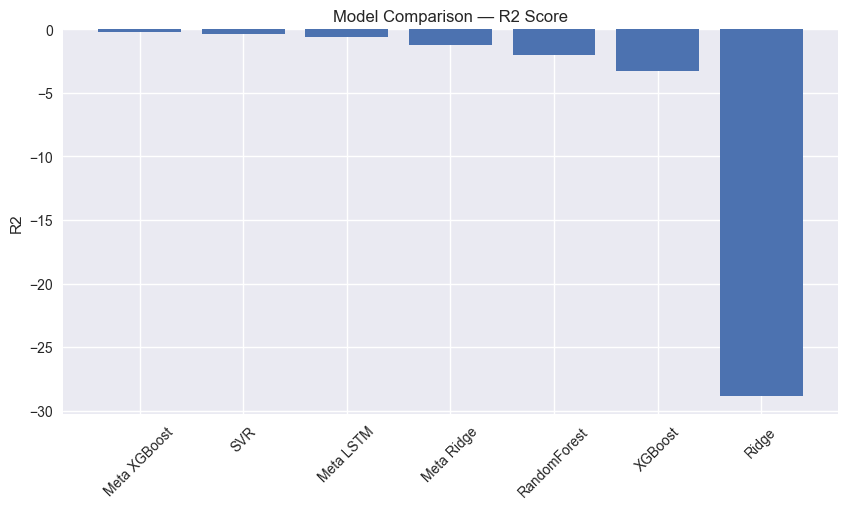

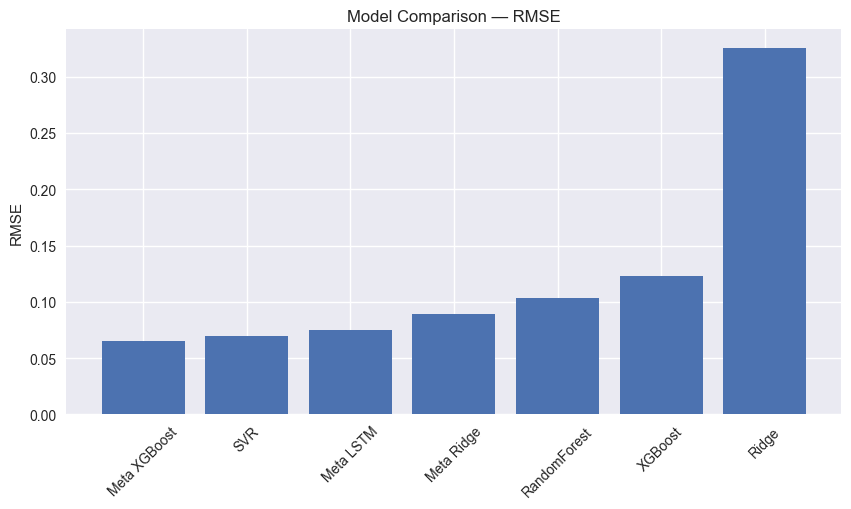

In [50]:
import matplotlib.pyplot as plt

# R2 Plot
plt.figure(figsize=(10,5))

plt.bar(comparison_df["Model"], comparison_df["R2"])

plt.title("Model Comparison — R2 Score")
plt.ylabel("R2")
plt.xticks(rotation=45)

plt.show()


# RMSE Plot
plt.figure(figsize=(10,5))

plt.bar(comparison_df["Model"], comparison_df["RMSE"])

plt.title("Model Comparison — RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)

plt.show()

##### Actual vs Prediction

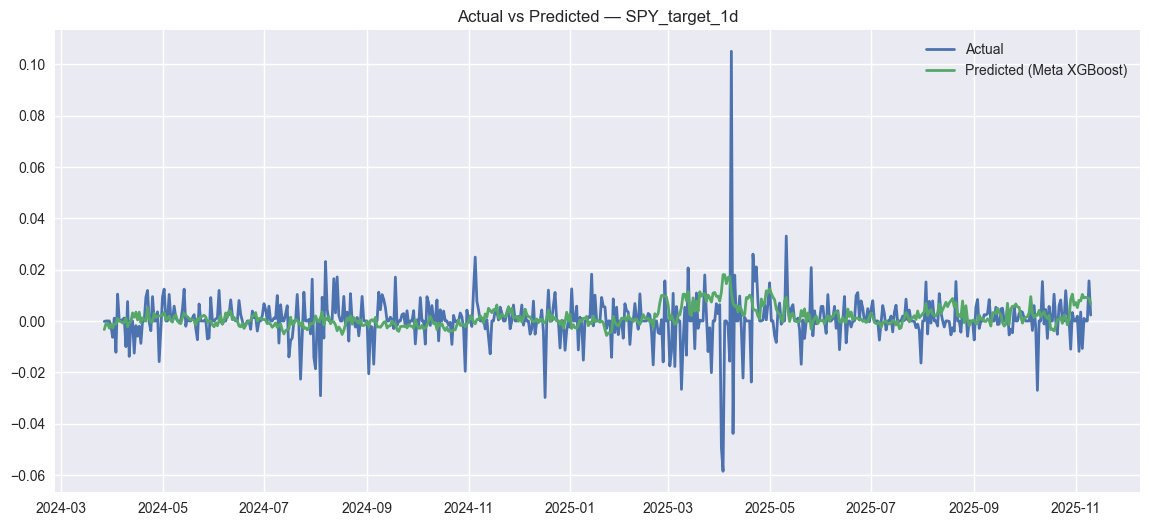

In [51]:
best_model_name = comparison_df.iloc[0]["Model"]

best_preds = models[best_model_name]

target_col = y_test_aligned.columns[0]  # example first asset

plt.figure(figsize=(14,6))

plt.plot(
    y_test_aligned[target_col],
    label="Actual",
    linewidth=2
)

plt.plot(
    best_preds[target_col],
    label=f"Predicted ({best_model_name})",
    linewidth=2
)

plt.title(f"Actual vs Predicted — {target_col}")
plt.legend()

plt.show()

### Walk Forward Validation

#### Define Walk-Forward Validation Function

In [53]:
import numpy as np
import pandas as pd

def walk_forward_meta(features, target, meta_model, horizon_list=[1,5,15,30,50], train_size = 0.7):
    n_obs = len(features)
    train_end = int(n_obs * train_size)
    
    # Prepare empty prediction DataFrames
    prediction_list = {h: pd.DataFrame(index=features.index[train_end:], columns=target.columns) for h in horizon_list}
    
    # Walk-forward loop
    for i in range(train_end, n_obs):
        X_train = features.iloc[:i]
        y_train = target.iloc[:i]  # train all past data
        
        X_test = features.iloc[i:i+1]  # current row
        
        # Train meta model
        meta_model.fit(X_train, y_train)
        
        # Predict for each horizon
        for h in horizon_list:
            test_index = i + h - 1
            if test_index >= n_obs:
                continue  # skip if horizon exceeds data
            
            X_horizon = features.iloc[i:test_index+1]
            pred = meta_model.predict(X_horizon)[-1]  # take last row
            
            # Assign to prediction DataFrame
            prediction_list[h].iloc[test_index - train_end] = pred  # align index
    
    # Convert to numeric
    for h in horizon_list:
        prediction_list[h] = prediction_list[h].astype(float)
    
    return prediction_list

#### Horizon Prediction using Meta XGBoost

In [54]:
from xgboost import XGBRegressor

meta_xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, verbosity=0)

horizons = [1,5,15,30,50]

meta_prediction = walk_forward_meta(
    features=meta_X_test, 
    target=meta_y_test, 
    meta_model=meta_xgb_model, 
    horizon_list=horizons, 
    train_size=0.7
)

#### Visualize the Results

##### Visualization Function

In [ ]:
import matplotlib.pyplot as plt

def plot_wfv_pred(meta_pred_dict, actual, asset, horizons=[1,5,15,30,50]):
    plt.figure(figsize=(14,6))
    
    # Plot actual data
    plt.plot(actual.index, actual[asset], label='Actual', color='black', linewidth=1.5)
    
    # Plot each horizon
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for h, c in zip(horizons, colors):
        if h in meta_pred_dict:
            plt.plot(meta_pred_dict[h].index, meta_pred_dict[h][asset], 
                     label=f'Pred Horizon {h}', color=c, alpha=0.7)
    
    plt.title(f'Walk-Forward Predictions vs Actual ({asset})')
    plt.xlabel('Date')
    plt.ylabel('Return / Price')
    plt.legend()
    plt.show() 

In [ ]:
asset_to_plot = meta_y_test.columns[0]  # first asset column
plot_wfv_pred(meta_prediction, meta_y_test, asset=asset_to_plot, horizons=[1,5,15,30,50])